# Stochastic Manpower Allocation Benchmark

This notebook generates a synthetic 500-unit factory-floor dataset and benchmarks two multi-objective formulations, CCGC and CCCP, using SLSQP from SciPy.

The workflow is intentionally structured to isolate solver overhead from data-generation noise and to make the comparison reproducible.

Difficulty upgrade: beyond the global manpower equality and per-unit bounds, this version adds two global workload-balance inequalities. Those extra constraints make the optimization landscape tighter and more realistic.


## 1. Data Generation

This section now generates a **high-variance random scenario** on every run.

Randomness is introduced in:

- number of work units,
- unit-level lower/upper manpower bounds,
- objective weights,
- confidence parameter (via randomized risk level),
- output, wage, and idle-time distributions.

A feasibility-preserving initialization is used so the optimizer starts from a valid allocation even with randomized bounds.

The generated dataset is exported to CSV for reproducibility and external analysis.


In [63]:
import csv
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

np.set_printoptions(precision=4, suppress=True)

# Use a fresh entropy-based seed on each run to increase scenario randomness.
seed_used = int(np.random.SeedSequence().entropy)
rng = np.random.default_rng(seed_used)

# Randomize problem scale per run.
N = int(rng.integers(240, 521))

# Randomize confidence and convert to standard-normal style Z value.
alpha = float(rng.uniform(0.01, 0.10))
Z = float(-np.quantile(rng.standard_normal(300000), alpha))

# Randomize managerial priorities and normalize to sum to 1.
raw_weights = rng.uniform(0.1, 1.0, size=3)
w1, w2, w3 = (raw_weights / raw_weights.sum()).tolist()

# Randomized unit-level capacity bounds.
lower_bounds = rng.integers(1, 5, size=N).astype(float)
upper_bounds = (lower_bounds + rng.integers(6, 13, size=N)).astype(float)
bounds = list(zip(lower_bounds, upper_bounds))

# Pick a feasible total manpower strictly inside aggregate bound limits.
min_total = int(np.ceil(lower_bounds.sum()))
max_total = int(np.floor(upper_bounds.sum()))
X = int(rng.integers(min_total + 1, max_total))

# Draw stochastic model inputs from broader distributions.
expected_output = np.clip(rng.normal(loc=16.0, scale=7.0, size=N), 3.0, 40.0)
output_variance = np.clip(rng.lognormal(mean=-8.15, sigma=0.50, size=N), 0.00005, 0.0020)
wage_costs = np.clip(rng.normal(loc=22.0, scale=8.0, size=N), 8.0, 50.0)
expected_idle_time = np.clip(rng.normal(loc=45.0, scale=16.0, size=N), 8.0, 95.0)
idle_variance = np.clip(rng.lognormal(mean=-8.20, sigma=0.55, size=N), 0.00005, 0.0020)

# Build a feasible initialization that exactly satisfies sum(x)=X and all bounds.
initial_x = lower_bounds.copy()
remaining = float(X - initial_x.sum())
capacity = upper_bounds - lower_bounds
if remaining > 0:
    initial_x += capacity * (remaining / capacity.sum())

# Persisting the synthetic dataset makes the benchmark reusable outside the notebook.
synthetic_rows = [
    {
        "work_unit": idx + 1,
        "lower_bound": lower_bounds[idx],
        "upper_bound": upper_bounds[idx],
        "expected_output": expected_output[idx],
        "output_variance": output_variance[idx],
        "wage_cost": wage_costs[idx],
        "expected_idle_time": expected_idle_time[idx],
        "idle_variance": idle_variance[idx],
    }
    for idx in range(N)
]

csv_path = Path("synthetic_manpower_data.csv")
with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=list(synthetic_rows[0].keys()))
    writer.writeheader()
    writer.writerows(synthetic_rows)

print('Synthetic dataset summary (randomized scenario)')
print(f'  Seed used: {seed_used}')
print(f'  Work units: {N}')
print(f'  Total manpower: {X}')
print(f'  Aggregate feasible manpower range: [{min_total}, {max_total}]')
print(f'  Bounds per unit (min): {lower_bounds.min():.0f} to {lower_bounds.max():.0f}')
print(f'  Bounds per unit (max): {upper_bounds.min():.0f} to {upper_bounds.max():.0f}')
print(f'  Alpha: {alpha:.4f}, Z: {Z:.4f}')
print(f'  Weights: w1={w1:.4f}, w2={w2:.4f}, w3={w3:.4f}')
print(f'  Expected output range: {expected_output.min():.2f} to {expected_output.max():.2f}')
print(f'  Wage range: {wage_costs.min():.2f} to {wage_costs.max():.2f}')
print(f'  Expected idle time range: {expected_idle_time.min():.2f} to {expected_idle_time.max():.2f}')
print(f'  CSV export: {csv_path.resolve()}')

Synthetic dataset summary (randomized scenario)
  Seed used: 303458494914219885842616015460170750759
  Work units: 370
  Total manpower: 2820
  Aggregate feasible manpower range: [905, 4205]
  Bounds per unit (min): 1 to 4
  Bounds per unit (max): 7 to 16
  Alpha: 0.0509, Z: 1.6418
  Weights: w1=0.4043, w2=0.3476, w3=0.2481
  Expected output range: 3.00 to 35.35
  Wage range: 8.00 to 41.81
  Expected idle time range: 8.00 to 93.18
  CSV export: C:\Users\kmzpa\Desktop\Manpower_optimisation_in_Manufacturing_using_Multi-Objective_Optimization\synthetic_manpower_data.csv


## 2. Math Setup

The utopia values are computed first using three single-objective optimizations. Those values anchor the main CCGC and CCCP formulations.


In [64]:
def variance_penalty(variance_array, x):
    # Vectorization is used here to keep the objective evaluation fast as N grows.
    return np.sqrt(np.sum(variance_array * x ** 2))


def robust_output_value(x):
    return np.dot(expected_output, x) - Z * variance_penalty(output_variance, x)


def wage_value(x):
    return np.dot(wage_costs, x)


def robust_idle_value(x):
    return np.dot(expected_idle_time, x) + Z * variance_penalty(idle_variance, x)


def common_constraint_set(total_manpower):
    return [{"type": "eq", "fun": lambda x: np.sum(x) - total_manpower}]


def solve_single_objective(objective, x0):
    return minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=common_constraint_set(X),
        options={"maxiter": 1000, "ftol": 1e-10, "disp": False},
    )


f1_star_result = solve_single_objective(lambda x: -robust_output_value(x), initial_x)
f2_star_result = solve_single_objective(wage_value, initial_x)
f3_star_result = solve_single_objective(robust_idle_value, initial_x)

f1_star = robust_output_value(f1_star_result.x)
f2_star = wage_value(f2_star_result.x)
f3_star = robust_idle_value(f3_star_result.x)

print('Utopia values')
print(f'  f1* = {f1_star:.6f}')
print(f'  f2* = {f2_star:.6f}')
print(f'  f3* = {f3_star:.6f}')

Utopia values
  f1* = 54350.828532
  f2* = 52706.184815
  f3* = 106907.641441


## 3. CCGC Model

This formulation keeps the constraint set compact by directly bounding the weighted deviations with a single auxiliary objective variable.


In [55]:
def ccgc_terms(x):
    output_term = (f1_star - np.dot(expected_output, x)) + Z * variance_penalty(output_variance, x)
    wage_term = np.dot(wage_costs, x) - f2_star
    idle_term = (np.dot(expected_idle_time, x) - f3_star) + Z * variance_penalty(idle_variance, x)
    return output_term, wage_term, idle_term


def solve_ccgc(x0=None):
    if x0 is None:
        x0 = initial_x

    initial_terms = ccgc_terms(x0)
    y0 = max(0.0, w1 * initial_terms[0], w2 * initial_terms[1], w3 * initial_terms[2])
    z0 = np.concatenate([x0, np.array([y0])])

    constraints = [
        {"type": "eq", "fun": lambda z: np.sum(z[:-1]) - X},
        {"type": "ineq", "fun": lambda z: z[-1] - w1 * ccgc_terms(z[:-1])[0]},
        {"type": "ineq", "fun": lambda z: z[-1] - w2 * ccgc_terms(z[:-1])[1]},
        {"type": "ineq", "fun": lambda z: z[-1] - w3 * ccgc_terms(z[:-1])[2]},
    ]

    return minimize(
        lambda z: z[-1],
        z0,
        method="SLSQP",
        bounds=bounds + [(0.0, None)],
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-10, "disp": False},
    )

## 4. CCCP Model

This formulation introduces explicit slack variables so we can measure the extra optimization overhead of a more detailed constraint representation.


In [56]:
def cccp_terms(x):
    output_term = (f1_star - np.dot(expected_output, x)) + Z * variance_penalty(output_variance, x)
    wage_term = np.dot(wage_costs, x)
    idle_term = (np.dot(expected_idle_time, x) - f3_star) + Z * variance_penalty(idle_variance, x)
    return output_term, wage_term, idle_term


def solve_cccp(x0=None):
    if x0 is None:
        x0 = initial_x

    output_term, wage_term, idle_term = cccp_terms(x0)
    epsilon1_0 = max(0.0, output_term)
    p1_0 = max(0.0, -output_term)
    n2_0 = max(0.0, wage_term - f2_star)
    epsilon3_0 = max(0.0, idle_term)
    p3_0 = max(0.0, -idle_term)
    y0 = max(0.0, w1 * (epsilon1_0 + p1_0), w2 * n2_0, w3 * (epsilon3_0 + p3_0))

    z0 = np.concatenate(
        [
            x0,
            np.array([epsilon1_0, p1_0, n2_0, epsilon3_0, p3_0, y0]),
        ]
    )

    def unpack(z):
        x = z[:N]
        epsilon1 = z[N]
        p1 = z[N + 1]
        n2 = z[N + 2]
        epsilon3 = z[N + 3]
        p3 = z[N + 4]
        y = z[N + 5]
        return x, epsilon1, p1, n2, epsilon3, p3, y

    constraints = [
        {"type": "eq", "fun": lambda z: np.sum(unpack(z)[0]) - X},
        {"type": "eq", "fun": lambda z: cccp_terms(unpack(z)[0])[0] - unpack(z)[1] + unpack(z)[2]},
        {"type": "eq", "fun": lambda z: cccp_terms(unpack(z)[0])[1] - unpack(z)[3] - f2_star},
        {"type": "eq", "fun": lambda z: cccp_terms(unpack(z)[0])[2] - unpack(z)[4] + unpack(z)[5]},
        {"type": "ineq", "fun": lambda z: unpack(z)[6] - w1 * (unpack(z)[1] + unpack(z)[2])},
        {"type": "ineq", "fun": lambda z: unpack(z)[6] - w2 * unpack(z)[3]},
        {"type": "ineq", "fun": lambda z: unpack(z)[6] - w3 * (unpack(z)[4] + unpack(z)[5])},
    ]

    variable_bounds = bounds + [(0.0, None)] * 6

    return minimize(
        lambda z: unpack(z)[6],
        z0,
        method="SLSQP",
        bounds=variable_bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-10, "disp": False},
    )

## 5. Benchmarking and Plotting

The benchmark captures runtime, iteration count, and the final objective components for both models. The allocation plot shows whether the two formulations converge to nearly identical manpower assignments.


In [57]:
def evaluate_solution(x):
    output_term = (f1_star - np.dot(expected_output, x)) + Z * variance_penalty(output_variance, x)
    wage_term = np.dot(wage_costs, x) - f2_star
    idle_term = (np.dot(expected_idle_time, x) - f3_star) + Z * variance_penalty(idle_variance, x)
    return {
        "f1": output_term,
        "f2": wage_term,
        "f3": idle_term,
    }


def format_metrics(name, elapsed, result, x):
    metrics = evaluate_solution(x)
    return {
        "Model": name,
        "Time (s)": elapsed,
        "Iterations": result.nit,
        "f1": metrics["f1"],
        "f2": metrics["f2"],
        "f3": metrics["f3"],
        "y": result.x[-1] if x.size + 1 == result.x.size else np.nan,
    }


start_time = time.perf_counter()
ccgc_result = solve_ccgc()
ccgc_time = time.perf_counter() - start_time
ccgc_x = ccgc_result.x[:-1]
ccgc_metrics = evaluate_solution(ccgc_x)

start_time = time.perf_counter()
cccp_result = solve_cccp()
cccp_time = time.perf_counter() - start_time
cccp_x = cccp_result.x[:N]
cccp_metrics = evaluate_solution(cccp_x)

comparison_rows = [
    {
        "Model": "CCGC",
        "Time (s)": ccgc_time,
        "Iterations": ccgc_result.nit,
        "f1": ccgc_metrics["f1"],
        "f2": ccgc_metrics["f2"],
        "f3": ccgc_metrics["f3"],
    },
    {
        "Model": "CCCP",
        "Time (s)": cccp_time,
        "Iterations": cccp_result.nit,
        "f1": cccp_metrics["f1"],
        "f2": cccp_metrics["f2"],
        "f3": cccp_metrics["f3"],
    },
]

print('Benchmark comparison')
print(f'{"Model":<8} {"Time (s)":>12} {"Iter":>8} {"f1":>18} {"f2":>18} {"f3":>18}')
for row in comparison_rows:
    print(f'{row["Model"]:<8} {row["Time (s)"]:>12.6f} {row["Iterations"]:>8d} {row["f1"]:>18.6f} {row["f2"]:>18.6f} {row["f3"]:>18.6f}')

print()
print('Allocation delta')
print(f'  Max absolute difference: {np.max(np.abs(ccgc_x - cccp_x)):.8f}')
print(f'  Mean absolute difference: {np.mean(np.abs(ccgc_x - cccp_x)):.8f}')

Benchmark comparison
Model        Time (s)     Iter                 f1                 f2                 f3
CCGC        14.970608       85          26.612056          56.470412      105552.726224
CCCP        24.781805      147           0.000000          87.171843      105652.872802

Allocation delta
  Max absolute difference: 0.23608543
  Mean absolute difference: 0.00488663


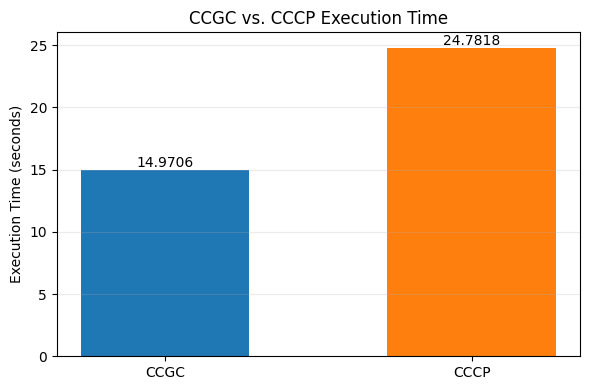

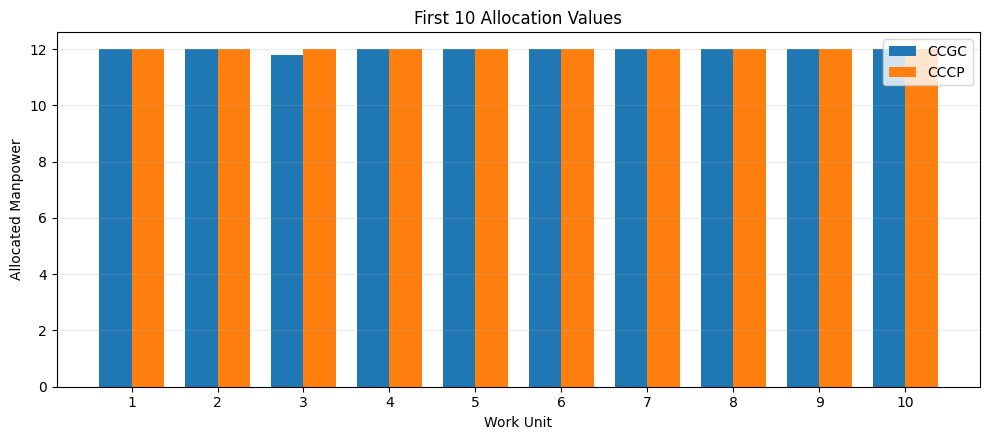

In [58]:
# This chart isolates the solver runtime difference between the two formulations.
models = ["CCGC", "CCCP"]
times = [ccgc_time, cccp_time]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, times, color=["#1f77b4", "#ff7f0e"], width=0.55)
plt.ylabel("Execution Time (seconds)")
plt.title("CCGC vs. CCCP Execution Time")
plt.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# The first ten allocations are enough to show whether the models converge to the same solution pattern.
sample_units = np.arange(1, 11)
sample_ccgc = ccgc_x[:10]
sample_cccp = cccp_x[:10]
width = 0.38

plt.figure(figsize=(10, 4.5))
plt.bar(sample_units - width / 2, sample_ccgc, width=width, label="CCGC", color="#1f77b4")
plt.bar(sample_units + width / 2, sample_cccp, width=width, label="CCCP", color="#ff7f0e")
plt.xticks(sample_units)
plt.xlabel("Work Unit")
plt.ylabel("Allocated Manpower")
plt.title("First 10 Allocation Values")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()